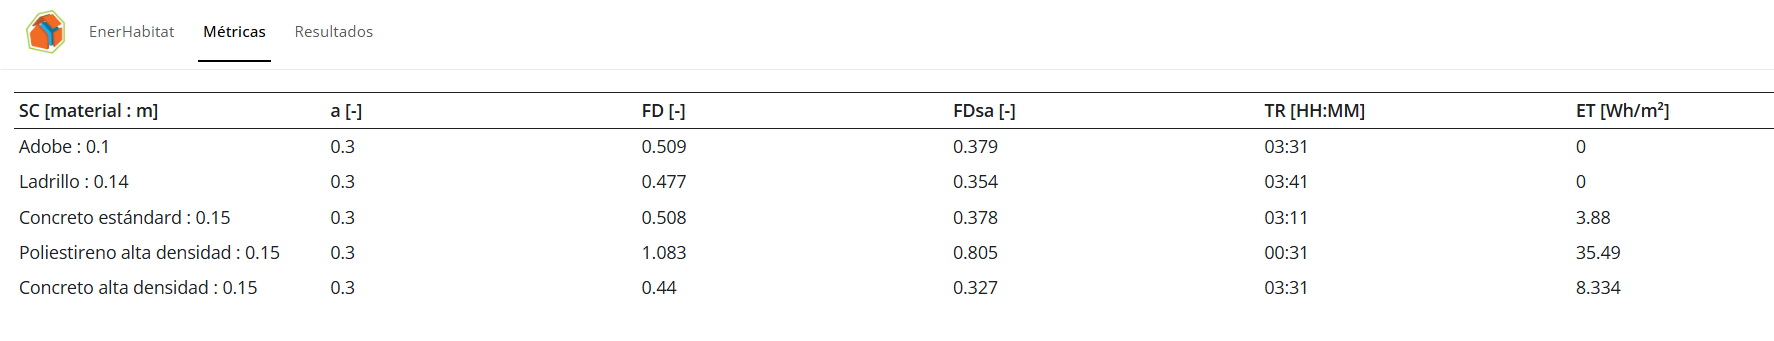

In [1]:
import enerhabitat as eh
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql

In [2]:

def evaluar(material, espesor,f):
    muro = eh.System(eh.Location(epw_file))
    muro.azimuth = 90
    muro.absortance = 0.3
    muro.layers = [(material,espesor)]
    muro.location.meanDay(month=5, year=2025)
    muro.Tsa()
    
    data, et  = muro.solve(energy=True)
    data = pd.concat([data,muro.Tsa().asfreq('10min')],axis=1)
    data.index = data.index.tz_localize(None)
    muro.info()
    
   
    adobe = read_sql(f,alias=True).data
    
    
    fig, ax = plt.subplots(2,1,figsize=(12,4))
    
    # ax[0].plot(data.Tsa,label='Tsa')
    ax[0].plot(data.Ti, label='Ti_EH')
    ax[0].plot(adobe.Ti_CUBO, label='Ti_E+')
    ax[0].legend()
    
    ax[1].plot(data.Is,label='Is')
    ax[1].plot(data.Ig,label='Ig')
    ax[1].legend()
    print(et)


In [3]:
eh.config.file = "materials.ini"
epw_file = "../epw/Temixco_2018CST.epw"


## Validacion Adobe 0.1

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Layers:
	1: Adobe, 0.1 m
0.0


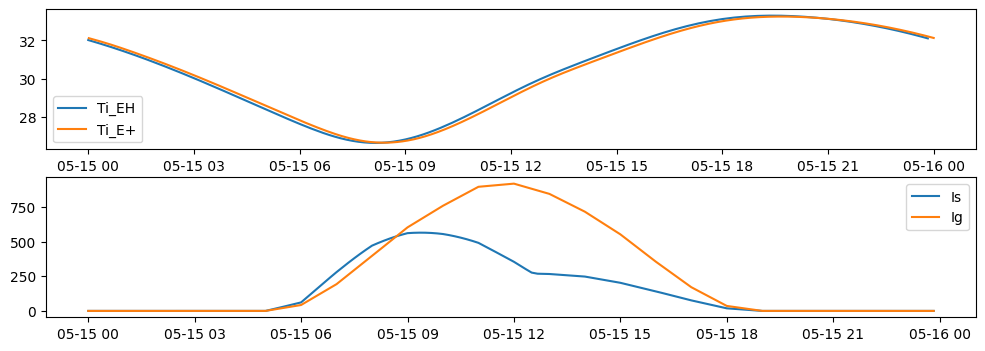

In [4]:
material = 'Adobe'
espesor = 0.1
f = '../idf/10cmAdobe.sql'

evaluar(material,espesor,f)

## Ladrillo 0.1 

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Layers:
	1: Ladrillo, 0.1 m
0.923885048751032


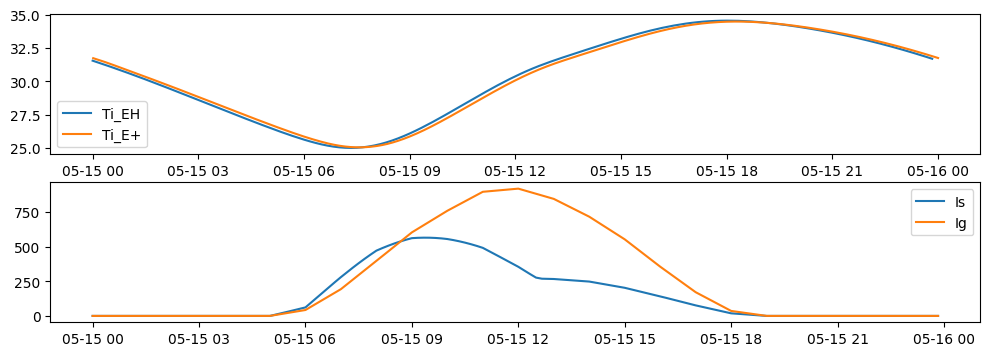

In [5]:
material = 'Ladrillo'
espesor = 0.10
f = '../idf/10cmLadrillo.sql'

evaluar(material,espesor,f)

## Concreto est'andard 0.1 

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Layers:
	1: Concreto, 0.1 m
123.69952850423047


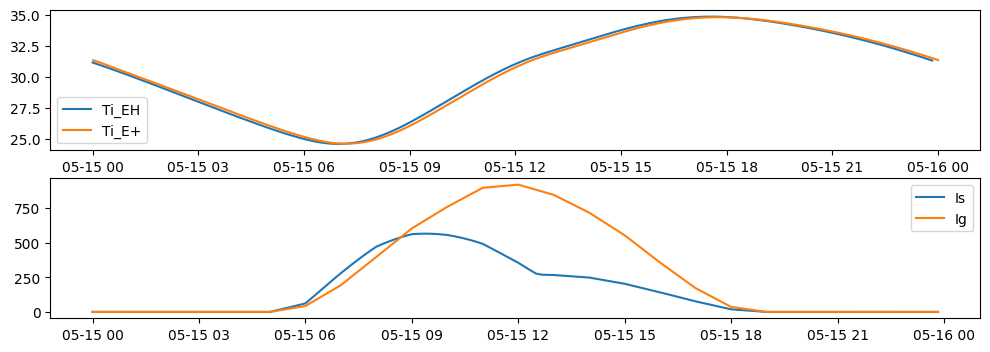

In [6]:
material = 'Concreto'
espesor = 0.10
f = '../idf/10cmConcreto.sql'

evaluar(material,espesor,f)

## EPS 0.10

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Layers:
	1: EPS, 0.15 m
35.49032708932202


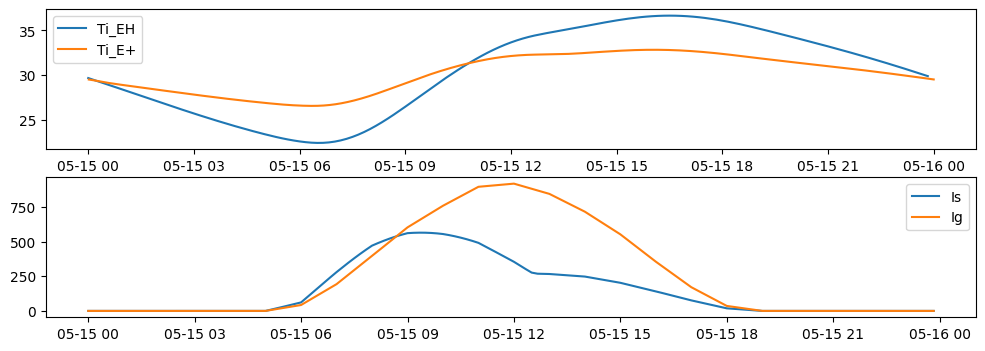

In [7]:
material = 'EPS'
espesor = 0.15
f = '../idf/10cmEPS.sql'

evaluar(material,espesor,f)

## CAD 0.1

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Layers:
	1: CAD, 0.1 m
509.6336878813597


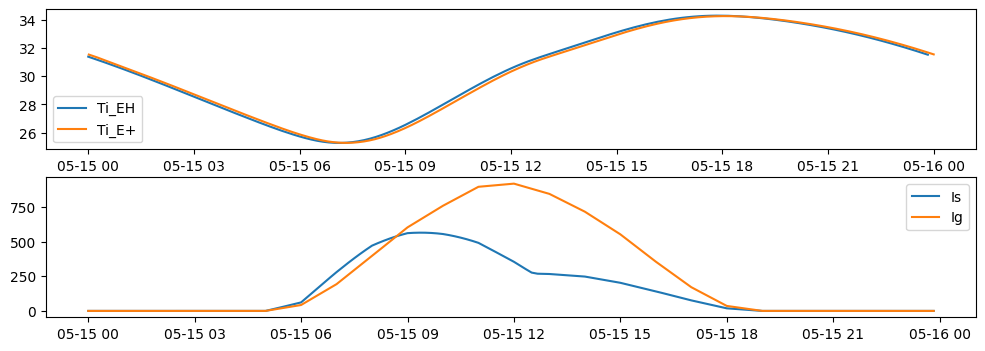

In [8]:
material = 'CAD'
espesor = 0.10
f = '../idf/10cmCAD.sql'

evaluar(material,espesor,f)

Adobe: 0.00
Ladrillo: 0.92
Concreto: 123.70
CAD: 509.63


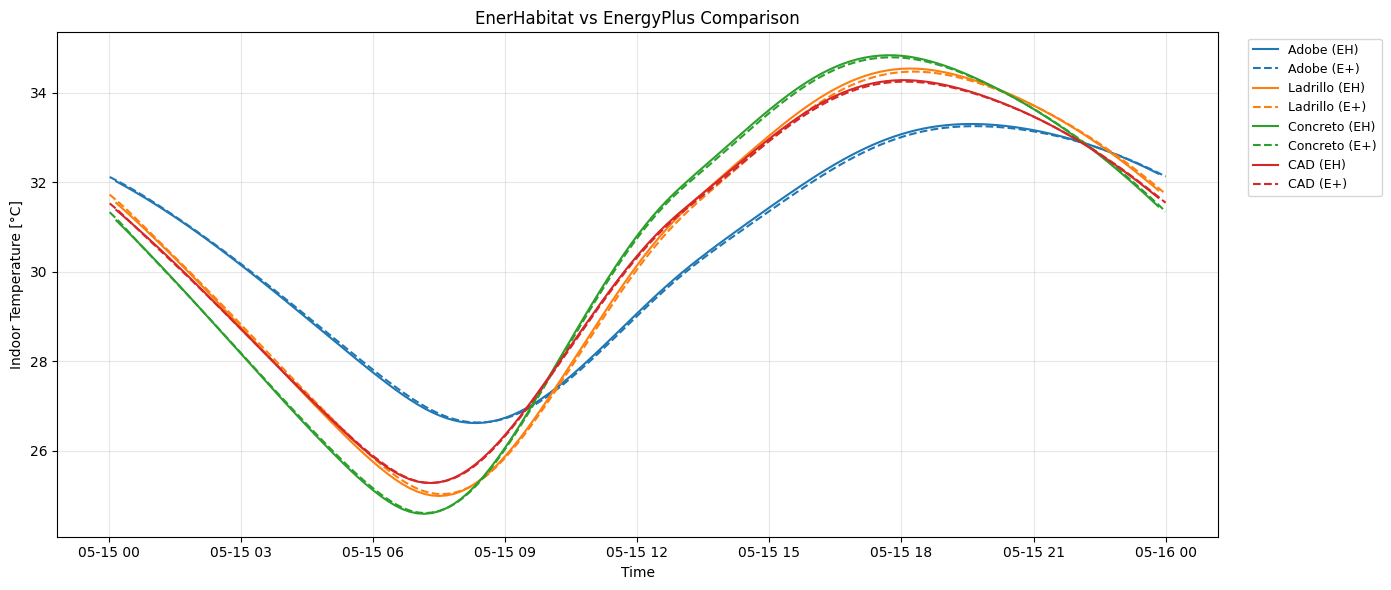

In [9]:
def evaluate_data(material, thickness, f):
    """Evaluates and returns data without plotting"""
    wall = eh.System(eh.Location(epw_file))
    wall.azimuth = 90
    wall.absortance = 0.3
    wall.layers = [(material, thickness)]
    wall.location.meanDay(month=5, year=2025)
    wall.Tsa()
    
    data, et = wall.solve(energy=True)
    data = pd.concat([data, wall.Tsa().asfreq('10min')], axis=1)
    data.index = data.index.tz_localize(None)
    
    eplus = read_sql(f, alias=True).data
    
    return {
        'Ti_EH': data.Ti.shift(1),
        'Ti_EP': eplus.Ti_CUBO,
        'et': et
    }

# Define all cases to evaluate
cases = [
    {'material': 'Adobe',    'thickness': 0.10, 'f': '../idf/10cmAdobe.sql'},
    {'material': 'Ladrillo',    'thickness': 0.10, 'f': '../idf/10cmLadrillo.sql'},
    {'material': 'Concreto', 'thickness': 0.10, 'f': '../idf/10cmConcreto.sql'},
    # {'material': 'EPS',    'thickness': 0.10, 'f': '../idf/10cmEPS.sql'},
    {'material': 'CAD',      'thickness': 0.10, 'f': '../idf/10cmCAD.sql'},
]

 
# Collect all results
results = {}
for case in cases:
    name = case['material']
    results[name] = evaluate_data(case['material'], case['thickness'], case['f'])
    print(f"{name}: {results[name]['et']:.2f}")

# Create consolidated visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Color palette
colors = plt.cm.tab10.colors

for i, (name, data) in enumerate(results.items()):
    color = colors[i]
    
    # EnerHabitat: solid line
    ax.plot(data['Ti_EH'], 
            color=color, 
            linestyle='-', 
            linewidth=1.5,
            label=f'{name} (EH)')
    
    # EnergyPlus: dashed line
    ax.plot(data['Ti_EP'], 
            color=color, 
            linestyle='--', 
            linewidth=1.5,
            label=f'{name} (E+)')

ax.set_xlabel('Time')
ax.set_ylabel('Indoor Temperature [°C]')
ax.set_title('EnerHabitat vs EnergyPlus Comparison')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()